# Hypothesis 1 And Concept-Copying Analysis (parametric)

Mirror of `result_analysis.ipynb` driven by two knobs in the setup cell:

- `MODEL_NAME` — selects the model whose cache to load (e.g. `"Qwen3-8B"`, `"Olmo-3-1025-7B"`, `"Llama-3.1-8B"`).
- `WEIGHTED` — flips between *raw* attention scores (`ntm_raw`/`ltm_raw`, sum of attention probabilities) and *value-weighted* scores (`ntm_value_weighted`/`ltm_value_weighted`, attn × value-norm, renormalized). The flag flows through every summary, plot, heatmap, and interpretation markdown downstream.

The notebook loads:

- `cache/improbable_bigrams/{MODEL_NAME}/updated_table1_literal/` — improbable bigrams
- `cache/improbable_bigrams/{MODEL_NAME}/selected_two_token_concepts/` — coherent 2-token concept control
- `cache/improbable_bigrams/{MODEL_NAME}/random_tokens/` — random two-token phrase control
- `cache/causal_scores/{MODEL_NAME}/{concept_copying,token_copying}_len30_n1024.json` — head rankings (Section 2)

To switch settings, edit `MODEL_NAME` and/or `WEIGHTED` in the setup cell and re-run all cells. Figure save dirs derive from `MODEL_SLUG`; figure filenames pick up `_raw`/`_weighted` suffixes so the variants don't overwrite each other.

In [29]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    candidates = []
    for candidate in (start, *start.parents):
        candidates.extend(
            [
                candidate,
                candidate / "dual-route-induction",
                candidate / "improbable-bigram-causality" / "dual-route-induction",
            ]
        )
    for candidate in candidates:
        if (candidate / "cache").exists() and (candidate / "scripts").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate the dual-route-induction repo root from the current working directory."
    )


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

import analysis_utils as h1

h1 = importlib.reload(h1)

h1.configure_matplotlib()

# One knob drives the whole notebook. Flip MODEL_NAME and re-run all cells to
# switch between models — figure dirs and cache lookups derive from this.
MODEL_NAME = "Llama-3.1-8B"  # e.g. "Olmo-3-1025-7B"
MODEL_SLUG = MODEL_NAME.lower().replace("-", "_").replace(".", "_")

# Toggle between raw NTM/LTM (sum of attention probabilities) and value-weighted
# NTM/LTM (attn × value-norm, renormalized). Affects every summary, plot, and
# heatmap downstream. Figure filenames pick up a suffix so the two variants
# don't overwrite each other on disk.
WEIGHTED = True
WEIGHTED_TAG = "weighted" if WEIGHTED else "raw"

CACHE = h1.load_cache(ROOT, model_name=MODEL_NAME)
DEFAULT_TOP_K = 32
ROOT

PosixPath('/u/sahuja1/improbable-bigram-causality/dual-route-induction')

In [40]:
CACHE

{'root': PosixPath('/u/sahuja1/improbable-bigram-causality/dual-route-induction'),
 'model_name': 'Qwen3-8B',
 'improbable_run': 'updated_table1_literal',
 'concept_run': 'selected_two_token_concepts',
 'random_run': 'random_tokens',
 'token_ranking': [(22, 23),
  (24, 22),
  (29, 15),
  (32, 5),
  (20, 26),
  (22, 21),
  (24, 23),
  (22, 22),
  (33, 28),
  (35, 26),
  (32, 6),
  (35, 2),
  (31, 28),
  (33, 31),
  (34, 28),
  (33, 7),
  (23, 4),
  (24, 20),
  (20, 21),
  (33, 30),
  (30, 26),
  (34, 17),
  (35, 25),
  (20, 22),
  (29, 11),
  (30, 5),
  (20, 25),
  (13, 28),
  (30, 7),
  (27, 25),
  (27, 26),
  (21, 22),
  (27, 23),
  (25, 13),
  (27, 27),
  (32, 14),
  (32, 10),
  (13, 13),
  (2, 31),
  (30, 24),
  (21, 21),
  (31, 11),
  (25, 6),
  (34, 8),
  (35, 8),
  (23, 21),
  (35, 9),
  (24, 2),
  (9, 8),
  (27, 12),
  (19, 16),
  (29, 14),
  (4, 4),
  (34, 6),
  (28, 29),
  (26, 15),
  (33, 16),
  (30, 12),
  (25, 15),
  (7, 23),
  (24, 29),
  (31, 5),
  (24, 30),
  (13, 15),
 

## Shared Cache Checks

Verify that the traced cache and both control caches are available before either analysis section.

In [30]:
display(Markdown(h1.trace_consistency_markdown(CACHE)))
overview = h1.dataset_overview(CACHE)
display(overview)

### Trace Consistency
The prompt-summary JSON is not present in this repo snapshot. The notebook therefore uses the traced cache directly.

,dataset,examples,hallucinated_second_token,copied
0,Improbable summary,100,34,66
1,Updated trace cache,100,34,66
2,2-token concept cache,36,0,36
3,Random phrase cache,35,0,35


# Hypothesis 1 Analysis

Token-induction diagnostics for Qwen3-8B on the improbable-bigram repetition setup:

- token induction heads should keep attending to the desired earlier suffix token, measured with `NTM`
- token induction heads should keep contributing to the correct second-token prediction, measured with `DLA`

Improbable trace lives in `updated_table1_literal/`; controls in `selected_two_token_concepts/` and `random_tokens/`.

In [31]:
summary = h1.build_pairwise_summary(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)
display(summary.round(6))
display(Markdown(h1.interpretation_markdown(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Token NTM (value-weighted),Hallucinated - Copied,0.423662,0.421492,0.002170,-0.005406,0.009860
1,Token NTM (value-weighted),Hallucinated - 2-token concepts,0.423662,0.354297,0.069365,0.054234,0.084792
2,Token NTM (value-weighted),Hallucinated - Random,0.423662,0.412943,0.010719,0.001748,0.019780
3,Token correct-token DLA,Hallucinated - Copied,0.029569,0.032569,-0.003000,-0.010059,0.003753
4,Token correct-token DLA,Hallucinated - 2-token concepts,0.029569,0.041691,-0.012122,-0.023053,-0.001455
5,Token correct-token DLA,Hallucinated - Random,0.029569,0.073341,-0.043772,-0.054996,-0.033278
6,Hallucinated token DLA,Wrong-token - Correct-token,0.001121,0.029569,-0.028448,-0.036075,-0.020549


### Hypothesis 1 Readout at Top-32
- Hallucinated vs copied NTM: `0.0022` (95% CI `-0.0054` to `0.0099`)
- Hallucinated vs copied correct-token DLA: `-0.0030` (95% CI `-0.0101` to `0.0038`)
- Hallucinated vs 2-token concepts NTM: `0.0694` (95% CI `0.0542` to `0.0848`)
- Hallucinated vs 2-token concepts correct-token DLA: `-0.0121` (95% CI `-0.0231` to `-0.0015`)
- Hallucinated vs random NTM: `0.0107` (95% CI `0.0017` to `0.0198`)
- Hallucinated vs random correct-token DLA: `-0.0438` (95% CI `-0.0550` to `-0.0333`)
- Hallucinated wrong-token minus correct-token DLA: `-0.0284` (95% CI `-0.0361` to `-0.0205`)

Within the improbable-bigram set, the traced cache does not show a clear hallucination-specific token-head breakdown. The stronger claim that token-head behavior is similar across all conditions is harder to defend, because the 2-token concept and random-phrase controls are both stronger on the token-head metrics.

,metric,condition,k,mean,ci_low,ci_high
0,Token NTM (value-weighted),Hallucinated improbable,8,0.539392,0.533129,0.545535
1,Token NTM (value-weighted),Copied improbable,8,0.537679,0.533488,0.541863
2,Token NTM (value-weighted),2-token concepts,8,0.482069,0.469118,0.494350
3,Token NTM (value-weighted),Random phrases,8,0.431032,0.420239,0.441704
4,Token NTM (value-weighted),Hallucinated improbable,16,0.553277,0.546945,0.559618
5,Token NTM (value-weighted),Copied improbable,16,0.552485,0.547674,0.557145
6,Token NTM (value-weighted),2-token concepts,16,0.455058,0.437633,0.472156
7,Token NTM (value-weighted),Random phrases,16,0.501880,0.493912,0.509690
8,Token NTM (value-weighted),Hallucinated improbable,32,0.423662,0.417749,0.429788
9,Token NTM (value-weighted),Copied improbable,32,0.421492,0.416954,0.426259


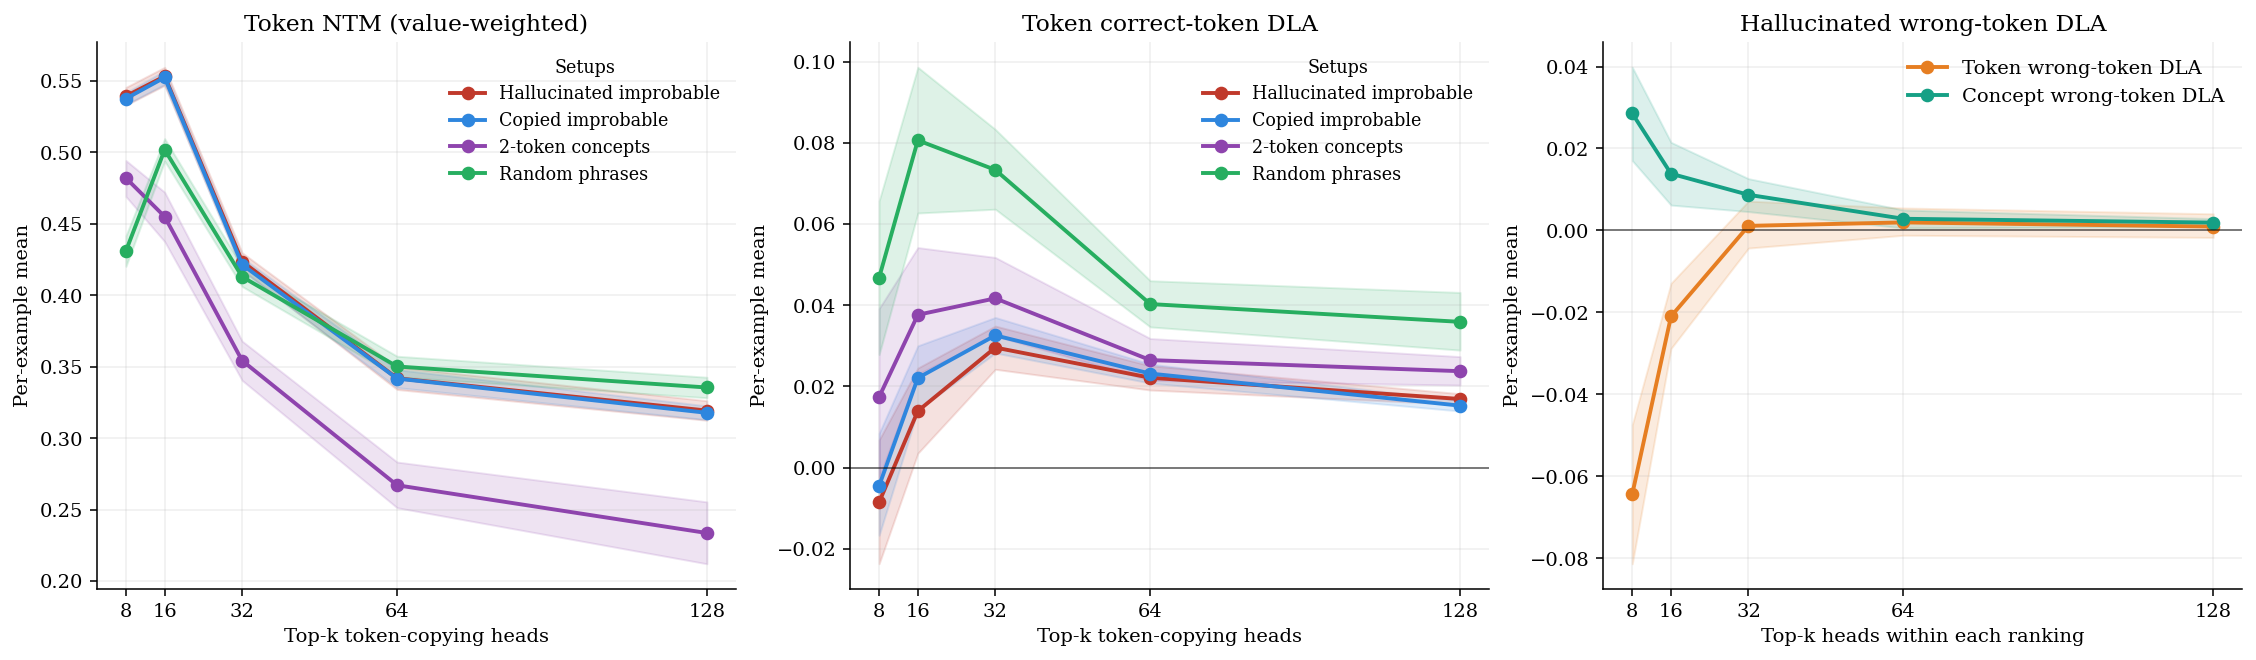

In [32]:
fig, axes, sweep = h1.plot_k_sweep(CACHE, ks=(8, 16, 32, 64, 128), weighted=WEIGHTED)
display(sweep.round(6))

In [ ]:
h1.plot_distribution_panels(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 token heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

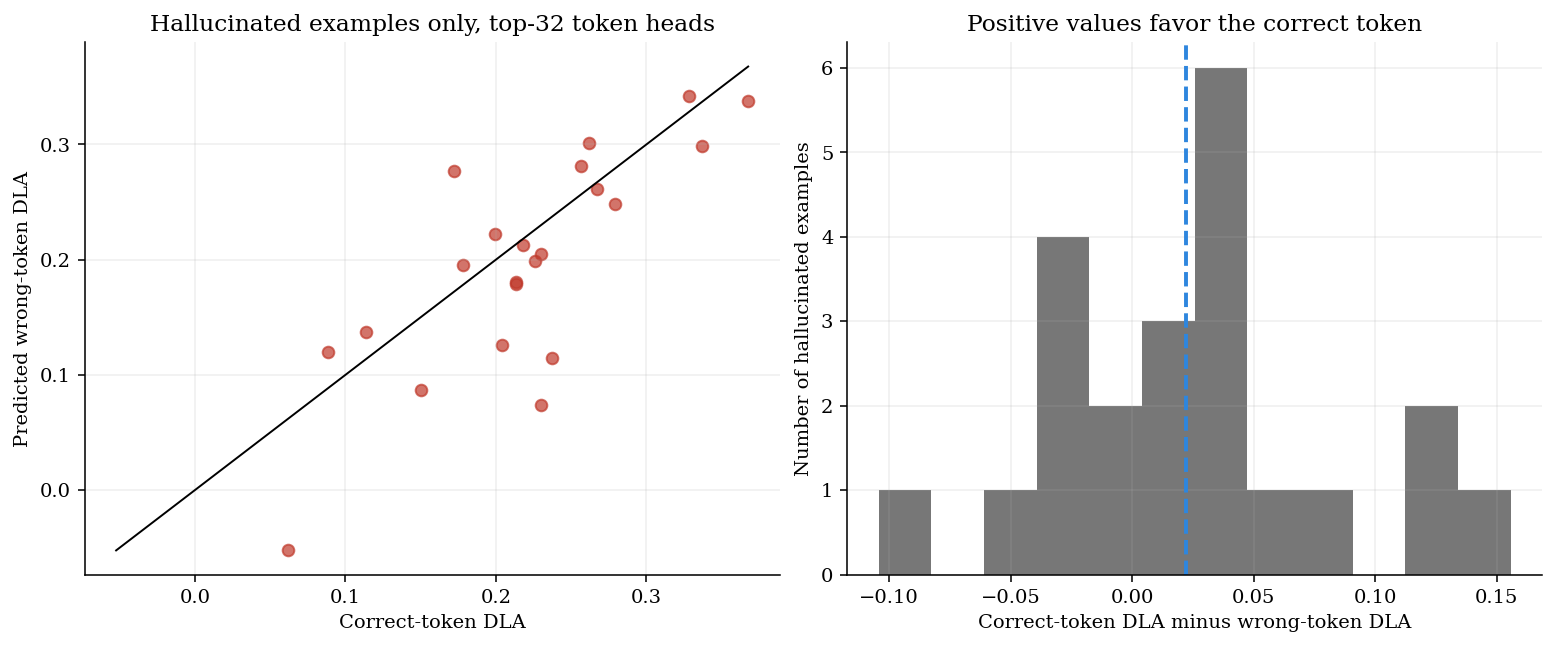

In [6]:
h1.plot_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

In [ ]:
h1.plot_top_head_heatmap(CACHE, top_k=16, weighted=WEIGHTED)

## Are The Highest-DLA Heads Token-Copying Or Concept-Copying?

Rank heads by mean DLA on each example subset and check membership in the token-copying and concept-copying top-K rankings.

In [16]:
TOP_DLA_N = 20
COMPARE_K = 32
SOURCES = [
    "hallucinated_correct",
    "hallucinated_wrong",
    "copied_correct",
    "concepts_correct",
    "random_correct",
]

membership_summary = h1.summarize_top_dla_membership(
    CACHE,
    sources=SOURCES,
    top_n=TOP_DLA_N,
    compare_k=COMPARE_K,
)
display(membership_summary)

for source in SOURCES:
    table = h1.top_dla_membership_table(
        CACHE,
        source=source,
        top_n=TOP_DLA_N,
        compare_k=COMPARE_K,
    )
    display(Markdown(f"### {table['source'].iloc[0]}"))
    display(
        table[
            [
                "head",
                "mean_dla",
                "membership_label",
                "in_token_top_k",
                "in_concept_top_k",
                "token_rank",
                "concept_rank",
            ]
        ].round({"mean_dla": 6})
    )

,source,top_n,compare_k,token_overlap,concept_overlap,both_overlap,neither_overlap,mean_token_rank,mean_concept_rank
0,Hallucinated correct-token DLA,20,32,3,2,0,15,349.50,624.70
1,Hallucinated wrong-token DLA,20,32,3,2,0,15,345.10,676.05
2,Copied-improbable correct-token DLA,20,32,4,2,0,14,343.65,638.15
3,2-token-concept correct-token DLA,20,32,4,1,0,15,319.60,768.85
4,Random-phrase correct-token DLA,20,32,4,0,0,16,355.45,717.15


### Hallucinated correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.688305,Token only,True,False,30,955
1,27.6,0.488522,Neither,False,False,882,371
2,26.3,0.401426,Neither,False,False,36,874
3,26.13,0.364736,Neither,False,False,308,190
4,22.1,0.319401,Neither,False,False,119,607
5,20.1,0.282793,Concept only,False,True,494,8
6,24.18,0.232462,Neither,False,False,132,994
7,31.21,0.223554,Neither,False,False,441,974
8,29.9,0.216471,Neither,False,False,549,999
9,28.22,0.197484,Neither,False,False,541,914


### Hallucinated wrong-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.435099,Token only,True,False,30,955
1,24.22,0.413221,Neither,False,False,183,619
2,29.9,0.291460,Neither,False,False,549,999
3,28.0,0.241133,Neither,False,False,306,860
4,30.26,0.229119,Neither,False,False,144,926
5,31.5,0.221403,Neither,False,False,534,951
6,26.3,0.198855,Neither,False,False,36,874
7,31.21,0.197255,Neither,False,False,441,974
8,25.7,0.193913,Neither,False,False,442,789
9,27.6,0.193628,Neither,False,False,882,371


...

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.653223,Token only,True,False,30,955
1,27.6,0.501448,Neither,False,False,882,371
2,26.13,0.363669,Neither,False,False,308,190
3,26.3,0.362918,Neither,False,False,36,874
4,29.9,0.254335,Neither,False,False,549,999
5,20.1,0.239196,Concept only,False,True,494,8
6,27.20,0.235168,Concept only,False,True,192,4
7,30.12,0.232389,Neither,False,False,873,864
8,31.20,0.211272,Neither,False,False,584,960
9,31.21,0.176189,Neither,False,False,441,974


### 2-token-concept correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,30.26,0.966518,Neither,False,False,144,926
1,29.9,0.806480,Neither,False,False,549,999
2,31.1,0.764443,Token only,True,False,30,955
3,27.20,0.554755,Concept only,False,True,192,4
4,29.11,0.543800,Neither,False,False,281,667
5,28.18,0.353730,Neither,False,False,108,762
6,31.7,0.315361,Neither,False,False,479,965
7,29.21,0.312236,Token only,True,False,8,937
8,31.6,0.280483,Neither,False,False,152,946
9,30.2,0.248536,Neither,False,False,950,928


### Random-phrase correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.0,0.801272,Token only,True,False,22,956
1,27.4,0.560181,Neither,False,False,522,743
2,30.12,0.420074,Neither,False,False,873,864
3,30.24,0.390628,Token only,True,False,13,831
4,28.20,0.367737,Neither,False,False,233,670
5,25.13,0.340523,Neither,False,False,697,856
6,25.14,0.339815,Neither,False,False,74,403
7,30.30,0.335793,Neither,False,False,73,889
8,24.18,0.334160,Neither,False,False,132,994
9,24.16,0.321873,Neither,False,False,411,787


In [ ]:
SAVE_DIR = ROOT / "scripts" / f"{MODEL_SLUG}_hypothesis1_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_k_sweep(
    CACHE,
    ks=(8, 16, 32, 64, 128),
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"hypothesis1_k_sweep_{WEIGHTED_TAG}.png",
)
_ = h1.plot_distribution_panels(
    CACHE,
    DEFAULT_TOP_K,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"hypothesis1_distributions_{WEIGHTED_TAG}.png",
)
_ = h1.plot_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "hypothesis1_hallucinated_dla_pair.png"
)
_ = h1.plot_top_head_heatmap(
    CACHE,
    top_k=16,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"hypothesis1_top_token_heads_{WEIGHTED_TAG}.png",
)
SAVE_DIR

---

# Concept-Copying Head Analysis

Mirrors `concept_copying_analysis.ipynb`. Reuses the same loaded cache and helper module.

## Coverage

Three conditions are present in the cache:

1. hallucinated improbable bigrams
2. random two-token phrases
3. coherent two-token concepts

Copied improbable examples serve as an additional internal control.

In [33]:
summary = h1.build_concept_pairwise_summary(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)
display(summary.round(6))
display(Markdown(h1.concept_interpretation_markdown(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Concept LTM (value-weighted),Hallucinated - Copied,0.194761,0.190779,0.003982,-0.002211,0.009883
1,Concept LTM (value-weighted),Hallucinated - 2-token concepts,0.194761,0.262264,-0.067504,-0.075226,-0.059455
2,Concept LTM (value-weighted),Hallucinated - Random,0.194761,0.168552,0.026209,0.018072,0.033961
3,Concept correct-token DLA,Hallucinated - Copied,0.014804,0.018565,-0.003762,-0.006129,-0.001487
4,Concept correct-token DLA,Hallucinated - 2-token concepts,0.014804,0.021799,-0.006996,-0.014558,0.000294
5,Concept correct-token DLA,Hallucinated - Random,0.014804,0.004973,0.009830,0.006660,0.012684
6,Hallucinated concept DLA,Wrong-token - Correct-token,0.008697,0.014804,-0.006106,-0.010368,-0.001993


### Concept-Head Readout at Top-32
- Hallucinated vs copied LTM: `0.0040` (95% CI `-0.0022` to `0.0099`)
- Hallucinated vs copied correct-token DLA: `-0.0038` (95% CI `-0.0061` to `-0.0015`)
- Hallucinated vs 2-token concepts LTM: `-0.0675` (95% CI `-0.0752` to `-0.0595`)
- Hallucinated vs 2-token concepts correct-token DLA: `-0.0070` (95% CI `-0.0146` to `0.0003`)
- Hallucinated vs random LTM: `0.0262` (95% CI `0.0181` to `0.0340`)
- Hallucinated vs random correct-token DLA: `0.0098` (95% CI `0.0067` to `0.0127`)
- Hallucinated wrong-token minus correct-token DLA: `-0.0061` (95% CI `-0.0104` to `-0.0020`)

The current cache includes hallucinated improbable bigrams, copied improbable prompts, coherent 2-token concepts, and random two-token phrases. That allows a direct check of whether concept-head behavior on hallucinated prompts looks more like the coherent concept condition or like the random-token control. In the current traced cache, concept heads do not cleanly separate hallucinated prompts from both copied improbable prompts and coherent 2-token concepts, and they do not strongly favor the wrong token over the correct token in hallucinated cases.

,metric,condition,k,mean,ci_low,ci_high
0,Concept LTM (value-weighted),Hallucinated improbable,8,0.354226,0.340311,0.365870
1,Concept LTM (value-weighted),Copied improbable,8,0.344396,0.337419,0.351286
2,Concept LTM (value-weighted),2-token concepts,8,0.536882,0.523926,0.549587
3,Concept LTM (value-weighted),Random phrases,8,0.264362,0.249245,0.279247
4,Concept LTM (value-weighted),Hallucinated improbable,16,0.270622,0.262342,0.278376
5,Concept LTM (value-weighted),Copied improbable,16,0.264152,0.259468,0.269107
6,Concept LTM (value-weighted),2-token concepts,16,0.376744,0.368204,0.384931
7,Concept LTM (value-weighted),Random phrases,16,0.215713,0.206488,0.224650
8,Concept LTM (value-weighted),Hallucinated improbable,32,0.194761,0.189375,0.199728
9,Concept LTM (value-weighted),Copied improbable,32,0.190779,0.187507,0.194104


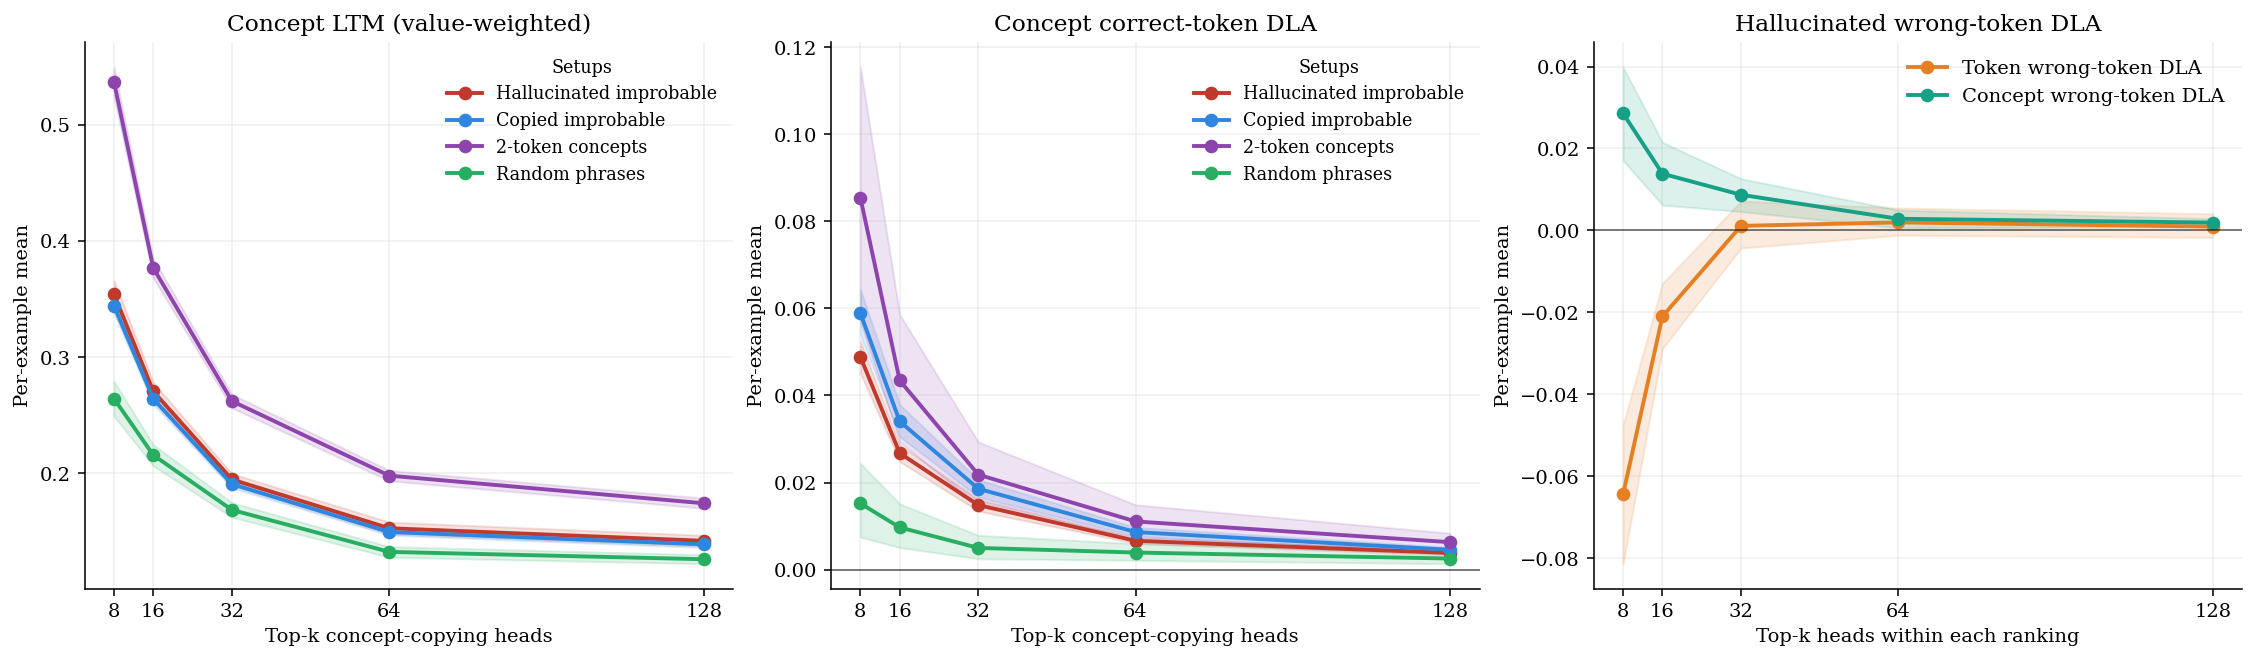

In [34]:
fig, axes, sweep = h1.plot_concept_k_sweep(CACHE, ks=(8, 16, 32, 64, 128), weighted=WEIGHTED)
display(sweep.round(6))

In [ ]:
h1.plot_concept_distribution_panels(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 concept heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

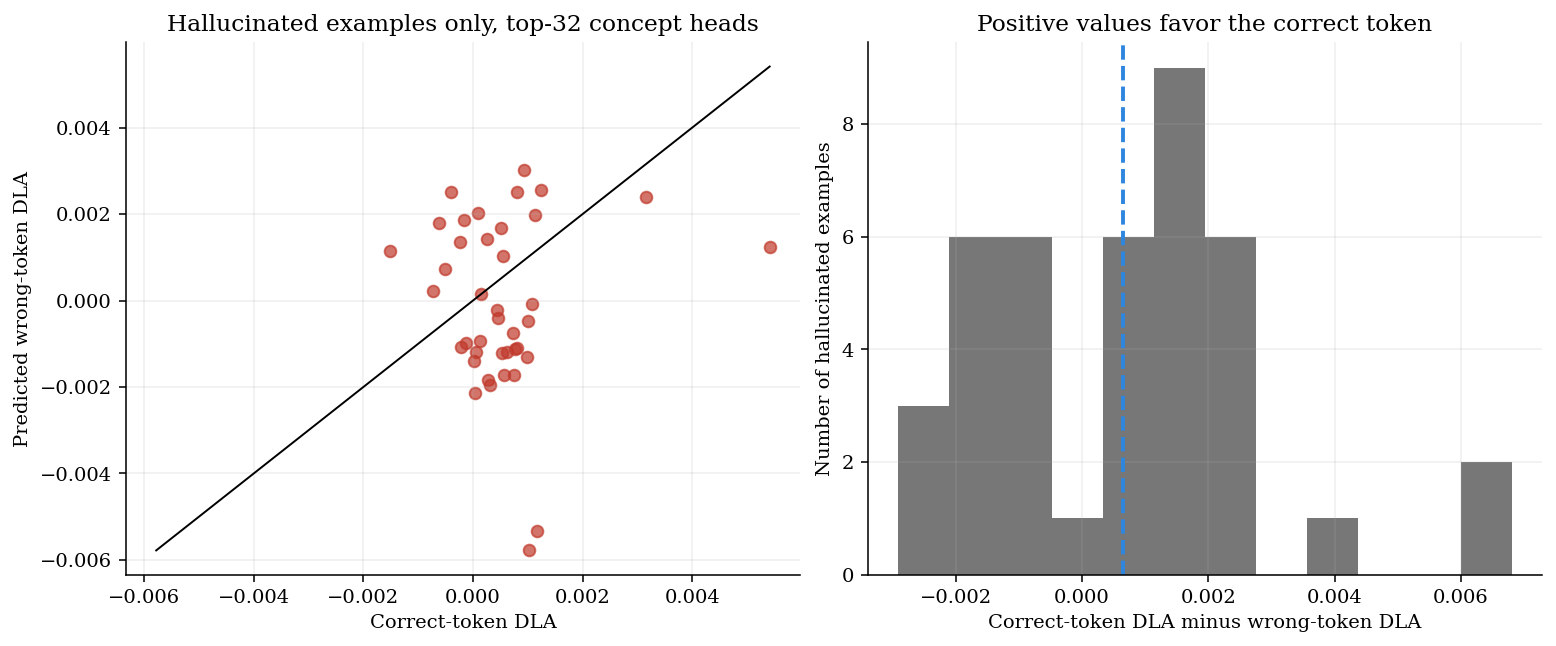

In [13]:
h1.plot_concept_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

In [ ]:
h1.plot_concept_head_heatmap(CACHE, top_k=16, weighted=WEIGHTED)

In [ ]:
SAVE_DIR = ROOT / "scripts" / f"{MODEL_SLUG}_concept_head_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_concept_k_sweep(
    CACHE,
    ks=(8, 16, 32, 64, 128),
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"concept_k_sweep_{WEIGHTED_TAG}.png",
)
_ = h1.plot_concept_distribution_panels(
    CACHE,
    DEFAULT_TOP_K,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"concept_distributions_{WEIGHTED_TAG}.png",
)
_ = h1.plot_concept_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "concept_hallucinated_dla_pair.png"
)
_ = h1.plot_concept_head_heatmap(
    CACHE,
    top_k=16,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"concept_top_heads_{WEIGHTED_TAG}.png",
)
SAVE_DIR